In [1]:
import os
import sys
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_NUM_INTRAOP_THREADS"] = "2"
os.environ["TF_NUM_INTEROP_THREADS"] = "2"
os.environ["OMP_NUM_THREADS"] = "2"
project_directory = Path.cwd()
if not (project_directory / "common.py").is_file():
    project_directory = project_directory.parent
sys.path.insert(0, str(project_directory))
from common import ROOT, MODE, SEED, BATCH, EPOCHS, CLASSES, ensure_data, split_paths, seed_all, load_array, evaluate_binary, save_metrics
seed_all()
print(f"Project: {ROOT.name} | mode: {MODE} | seed: {SEED}")


Project: land-classification-github | mode: quick | seed: 7331


In [2]:
import torch
from torchvision import datasets, transforms
from torch_models import ImagePaths, make_loader
from common import DATA
torch.set_num_threads(2)
train, val, test = split_paths()
print("Train / validation / test:", len(train[0]), len(val[0]), len(test[0]))
custom_loader = make_loader(*train, augment=True, shuffle=True, batch=8)
images, targets = next(iter(custom_loader))
print("Custom dataset batch:", tuple(images.shape), targets.tolist())


Train / validation / test: 336 72 72
Custom dataset batch: (8, 3, 64, 64) [0, 1, 0, 1, 1, 1, 1, 1]


In [3]:
image_folder = datasets.ImageFolder(DATA, transform=transforms.Compose([
    transforms.Resize((64, 64)), transforms.ToTensor()
]))
image_folder_loader = torch.utils.data.DataLoader(image_folder, batch_size=8)
folder_images, folder_targets = next(iter(image_folder_loader))
print("ImageFolder classes:", image_folder.class_to_idx)
print("ImageFolder batch:", tuple(folder_images.shape), folder_targets.tolist())


ImageFolder classes: {'class_0_non_agri': 0, 'class_1_agri': 1}
ImageFolder batch: (8, 3, 64, 64) [0, 0, 0, 0, 0, 0, 0, 0]


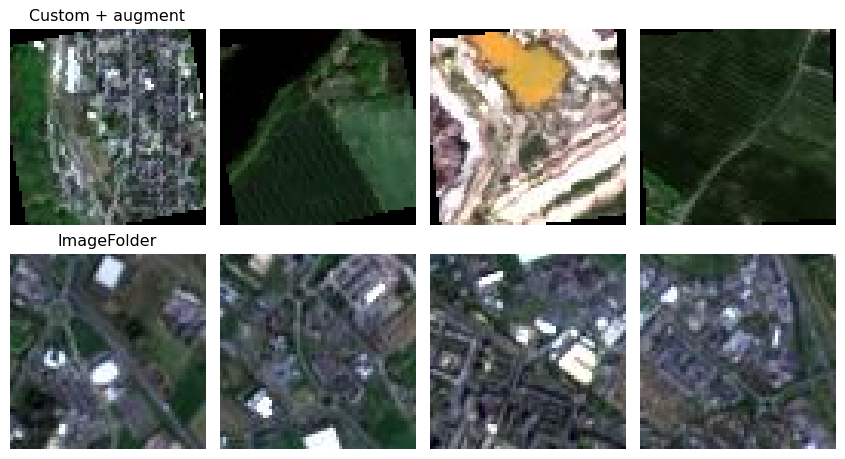

In [4]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 4, figsize=(9, 5))
for row, tensor_batch in enumerate((images, folder_images)):
    for column in range(4):
        axes[row, column].imshow(tensor_batch[column].permute(1, 2, 0).numpy())
        axes[row, column].axis("off")
axes[0, 0].set_title("Custom + augment")
axes[1, 0].set_title("ImageFolder")
plt.tight_layout()
plt.show()
